In [1]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

import csiborgtools

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_glamdring)
fdir = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity"

In [2]:
def rand_points_in_sphere(rmax, N):
    r = rmax * np.random.rand(N)**(1./3.)
    theta = np.arccos(2*np.random.rand(N)-1)
    phi = 2*np.pi*np.random.rand(N)
    return r[:, None] * np.vstack([
        np.sin(theta) * np.cos(phi),
        np.sin(theta) * np.sin(phi),
        np.cos(theta)]).T

In [3]:
ra, dec = csiborgtools.galactic_to_radec(117, 4)
csiborgtools.radec_to_cartesian(np.array([1., ra, dec]).reshape(-1, 3))

array([[ 0.4035093 , -0.01363162,  0.91487399]])

In [4]:
n_hat = np.asarray([0.4035093, -0.01363162, 0.91487399])

In [167]:
rLG, vx = csiborgtools.flow.load_void_fiducial("exp", "vrad")

2024-12-02 22:12:19   loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_new/sizenumber100/processed_fiducial_exp_vrad.hdf5`.


In [168]:
vx.shape

(51, 181, 251)

In [190]:
size, rLG, vrad = csiborgtools.flow.load_void_size_variation("exp", "vrad", "coarse")

2024-12-02 22:33:32   loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_new/processed_exp_vrad.hdf5`.


IndexError: boolean index did not match indexed array along dimension 0; dimension is 51 but corresponding boolean dimension is 48

In [189]:
size

array([ 0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,  1.1,
        1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  3. ,  4. ,
        5. ,  6. ,  7. ,  8. ,  9. , 10. , 11. , 12. , 13. , 14. , 15. ,
       16. , 17. , 18. , 19. , 20. , 21. , 22. , 23. , 24. , 25. , 26. ,
       27. , 28. , 29. , 30. ])

In [ ]:
r_grid = np.arange(0, 251)
phi_grid = np.arange(0, 181)


# size, rLG, vx = csiborgtools.flow.load_void_size_variation("exp", "vx")
size, rLG, vy = csiborgtools.flow.load_void_size_variation("exp", "vy")
size, rLG, vrad = csiborgtools.flow.load_void_size_variation("exp", "vrad")

# vvoid_mag = csiborgtools.flow.select_vvoid("exp")

# vvoid = vvoid_mag * np.asarray([-0.4035093, 0.01363162, -0.91487399])

2024-12-02 21:51:32   loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_new/processed_exp_vx.hdf5`.


Loading exp, vy void size variation data: 100%|██████████| 48/48 [01:06<00:00,  1.38s/it]

2024-12-02 21:55:14   dumping data to `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_new/processed_exp_vy.hdf5`.



Loading exp, vrad void size variation data: 100%|██████████| 48/48 [01:12<00:00,  1.50s/it]

2024-12-02 21:56:27   dumping data to `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_new/processed_exp_vrad.hdf5`.


In [185]:
(x * 100).astype(int)

array([  1,   2,   3,   4,   5,   6,   6,   8,   9,  10,  11,  12,  13,
        13,  15,  16,  17,  18,  19,  20,  30,  40,  50,  60,  70,  80,
        90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210,
       220, 229, 240, 250, 260, 270, 280, 290, 300])

In [ ]:
2.7 % 0.1

2.7755575615628914e-17

In [171]:
x = size / 10

In [183]:
m = (x * 100).astype(int) % 10 == 0

In [184]:
size[m]

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20., 21., 22., 24., 25., 26., 27.,
       28., 29., 30.])

In [178]:
2.1 % 0.1

0.09999999999999998

In [177]:
np.isclose(x % 0.1, 0)

array([False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False,  True, False,  True, False, False, False,  True, False,
       False,  True, False, False, False, False,  True, False, False,
       False, False, False,  True, False, False, False, False,  True,
       False, False, False])

In [107]:
size

array([ 0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,  1.1,
        1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  3. ,  4. ,
        5. ,  6. ,  7. ,  8. ,  9. , 10. , 11. , 12. , 13. , 14. , 15. ,
       16. , 17. , 18. , 19. , 20. , 21. , 22. , 23. , 24. , 25. , 26. ,
       27. , 28. , 29. , 30. ])

In [135]:
np.where(size == 1.)


(array([9]),)

In [109]:
vx.shape

(48, 51, 181, 251)

In [110]:
n = 27
k = 1

vy_grid = vy[n, k]
vx_grid = vx[n, k]
vrad_grid = vrad[n, k]

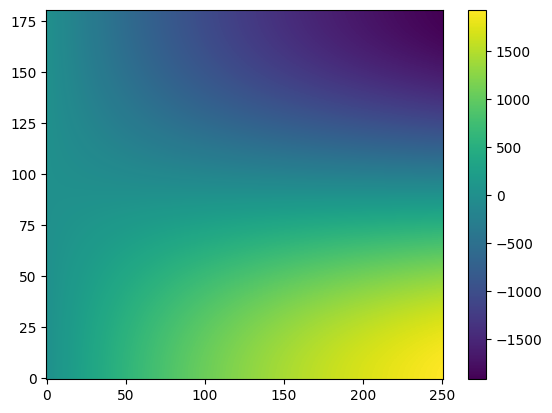

In [111]:
plt.figure()
plt.imshow(vx_grid, aspect="auto", origin="lower")
plt.colorbar()
plt.show()

In [8]:
# `vx_grid`, `vy_grid`, `vrad_grid` are of shape (251, 181)
phi_grid = np.arange(0, 181)
cos_phi = np.cos(np.deg2rad(phi_grid))

# Take a fixed slice of radial distance
i = 100
vrad_pred = vx_grid[:, i] * cos_phi + vy_grid[:, i] * np.sqrt(1 - cos_phi**2)
vrad_from_grid = vrad_grid[:, i]

# `vrad_pred` and `vrad_from_grid` do not agree


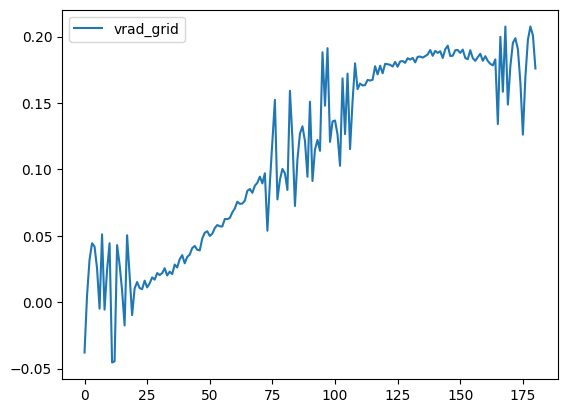

In [9]:
plt.figure()
# plt.plot(phi_grid, vrad_from_grid, label="vrad_grid")
# plt.plot(phi_grid, vrad_pred, label="vrad_pred")

plt.plot(phi_grid, vrad_from_grid - vrad_pred, label="vrad_grid")
# plt.plot(phi_grid, vrad_pred, label="vrad_pred")

plt.legend()


plt.show()

In [17]:
vx[k].shape

(181, 251)

In [160]:
rmax = 250
ngrid = 96

r_grid = np.arange(0, 251)
phi_grid = np.arange(0, 181)

r = np.linspace(0, rmax, 100)
k = 50
kgrid = 0


bulk_flow = csiborgtools.flow.void_bulk_flow(r, vx[kgrid,k], vy[kgrid, k], ngrid, r_grid, phi_grid, in_icrs=True)
# bulk_flow = csiborgtools.flow.void_bulk_flow(r, vx_grid, vy_grid, ngrid, r_grid, phi_grid, in_icrs=True)
monopole = csiborgtools.flow.void_monopole(r, vrad[kgrid, k], ngrid, r_grid, phi_grid)

# bulk_flow_from_vrad = csiborgtools.flow.void_bulk_flow_from_vrad(r, vrad[k], ngrid, r_grid, phi_grid)

100%|██████████| 100/100 [00:00<00:00, 392.14it/s]


In [161]:
x = [
     [150, 370.73150202137805, 6.699612175403815],
     [250, 303.44746978109833, 7.356051702500245],
     
     ]

In [162]:
vvoid =  np.asarray([-0.4035093, 0.01363162, -0.91487399])

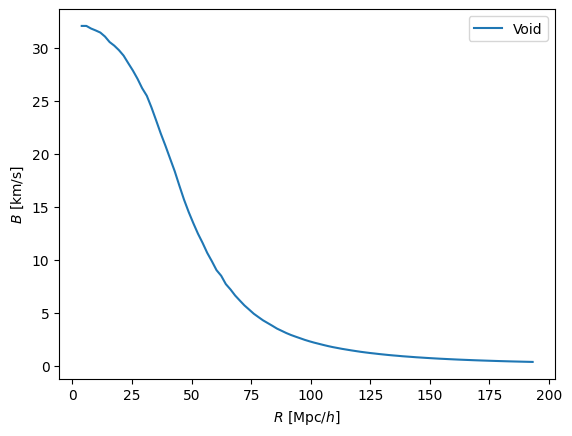

In [165]:
fig, ax = plt.subplots()

ax.plot(r * csiborgtools.flow.select_void_h("exp"),
         np.linalg.norm(bulk_flow + 0 * vvoid[None, :], axis=1), label="Void")

# ax.errorbar([150], [387], yerr=[28], fmt="o", label="Watkins")


x_watkins = np.asarray([99.47368421052632, 125.26315789473685, 150, 175.26315789473682, 200, 225.26315789473682, 249.4736842105263])
y_watkins = np.asarray([304.76190476190476, 347.6190476190476, 388.0952380952381, 407.1428571428571, 421.42857142857144, 426.19047619047615, 426.19047619047615])
m = x_watkins < 250 * csiborgtools.flow.select_void_h("exp")

# plt.plot(x_watkins[m], y_watkins[m], label="Watkins")

plt.xlabel(r"$R ~ [\mathrm{Mpc} / h]$")
plt.ylabel(r"$B ~ [\mathrm{km} / \mathrm{s}]$")

plt.legend()

# plt.plot(r, monopole)
# for r_, mu, scale in x:
    # plt.erroorbar(r_, mu, yerr=scale, fmt="o", color="red")

plt.savefig("../../plots/bf_example.png", dpi=300)

plt.show()

In [66]:
X = rand_points_in_sphere(rmax, 1000)

vel_icrs = csiborgtools.flow.void_velocity_vector(X, vx[k], vy[k], r_grid, phi_grid, return_icrs=True)
vel_void = csiborgtools.flow.void_velocity_vector(X, vx[k], vy[k], r_grid, phi_grid, return_icrs=False)

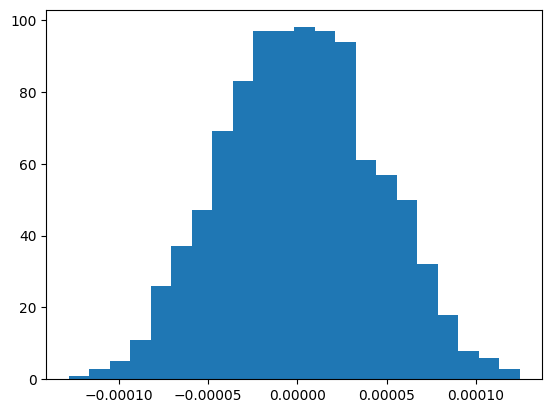

In [67]:
plt.figure()
plt.hist(np.linalg.norm(vel_icrs, axis=1) - np.linalg.norm(vel_void, axis=1), bins="auto")
plt.show()

In [68]:
vel_points = csiborgtools.flow.void_velocity_vector(
    rand_points_in_sphere(rmax, 10000),
    vx[k], vy[k], r_grid, phi_grid, return_icrs=True)

np.linalg.norm(np.mean(vel_points, axis=0))

19.876667414768978

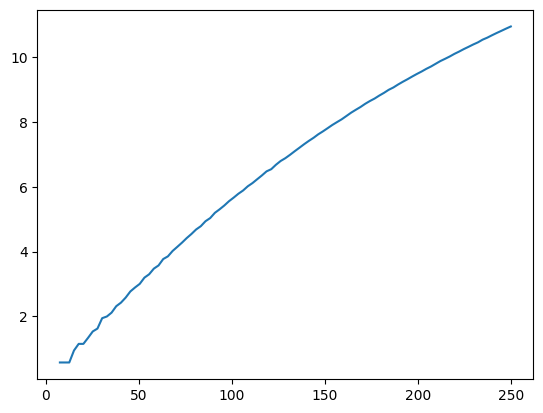

In [ ]:


x = boxsize / ngrid * (np.arange(ngrid) + 0.5) - boxsize / 2
X = np.vstack([x.reshape(-1,) for x in np.meshgrid(x, x, x)]).T




In [237]:
k = 3

vel, vx_test, vy_test = csiborgtools.flow.void_velocity_vector(X, vx[k], vy[k], r_grid, phi_grid)

ValueError: too many values to unpack (expected 3)

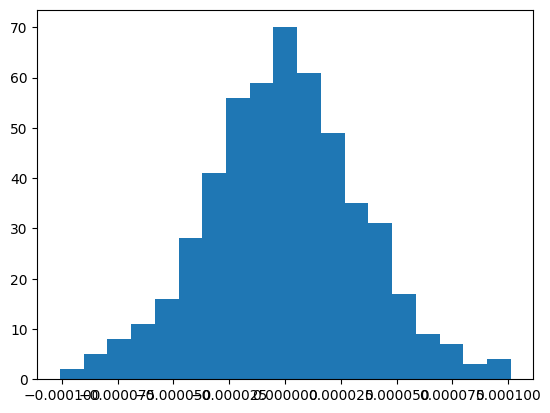

In [125]:
plt.figure()
plt.hist(np.linalg.norm(vel, axis=1) - np.sqrt(vx_test**2 + vy_test**2), bins="auto")
plt.show()

In [249]:
rmax = 150
boxsize = 2 * rmax
ngrid = 64

r = np.linspace(0, rmax, ngrid)

x = boxsize / ngrid * (np.arange(ngrid) + 0.5) - boxsize / 2
X = np.vstack([x.reshape(-1,) for x in np.meshgrid(x, x, x)]).T

In [254]:
k = 50

vel = csiborgtools.flow.void_velocity_vector(X, vx[k], vy[k], r_grid, phi_grid)


# V = 600 * np.asarray([0.4035093, -0.01363162, 0.91487399])

# vel += V[None, :]


In [255]:
Xtest = np.random.uniform(-rmax, rmax, (100000, 3))
rtest = np.linalg.norm(Xtest, axis=1)
m = rtest < rmax
Xtest = Xtest[m]
vel_test = csiborgtools.flow.void_velocity_vector(Xtest, vx[k], vy[k], r_grid, phi_grid)

In [256]:
np.linalg.norm(np.mean(vel_test, axis=0))

467.2466175376804

In [257]:
vx_grid = vel[..., 0].reshape(ngrid, ngrid, ngrid)
enclosed_vx, enclosed_vol = field_enclosed_mass(vx_grid, r, boxsize)
enclosed_vx /= enclosed_vol

vy_grid = vel[..., 1].reshape(ngrid, ngrid, ngrid)
enclosed_vy, enclosed_vol = field_enclosed_mass(vy_grid, r, boxsize)
enclosed_vy /= enclosed_vol

vz_grid = vel[..., 2].reshape(ngrid, ngrid, ngrid)  
enclosed_vz, enclosed_vol = field_enclosed_mass(vz_grid, r, boxsize)
enclosed_vz /= enclosed_vol


100%|██████████| 64/64 [00:00<00:00, 1241.87it/s]
/tmp/ipykernel_305238/209316873.py:3: RuntimeWarning: invalid value encountered in divide
  enclosed_vx /= enclosed_vol
100%|██████████| 64/64 [00:00<00:00, 1210.74it/s]
/tmp/ipykernel_305238/209316873.py:7: RuntimeWarning: invalid value encountered in divide
  enclosed_vy /= enclosed_vol
100%|██████████| 64/64 [00:00<00:00, 1251.90it/s]
/tmp/ipykernel_305238/209316873.py:11: RuntimeWarning: invalid value encountered in divide
  enclosed_vz /= enclosed_vol


In [258]:
bf_mag = np.sqrt(enclosed_vx**2 + enclosed_vy**2 + enclosed_vz**2)

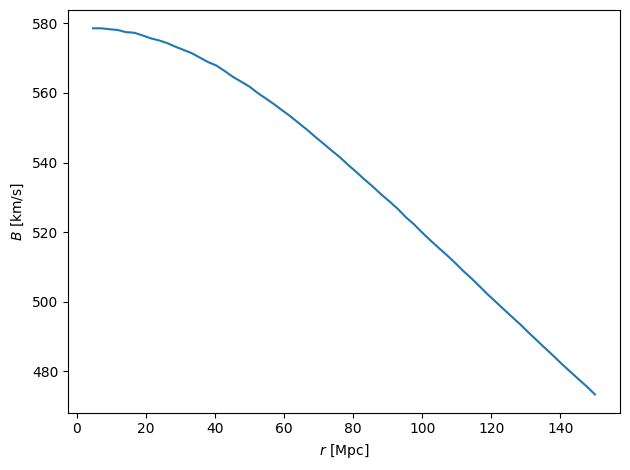

In [259]:
plt.figure()
plt.plot(r, bf_mag)
# plt.plot(r, enclosed_vx, label="vx")
# plt.plot(r, enclosed_vy, label="vy")
# plt.plot(r, enclosed_vz, label="vz")
plt.xlabel(r"$r ~ [\mathrm{Mpc}]$")
plt.ylabel(r"$B ~ [\mathrm{km / s}]$")
# plt.xlim(0, r.max())
plt.tight_layout()
plt.show()

(32768, 3)

In [189]:
# X = np.random.uniform(-250, 250, (100, 3))
gen = np.random.default_rng(42)
X = gen.uniform(-100, 100, (256**3, 3))

In [190]:
x = csiborgtools.flow.void_velocity_vector(X, vx[0], vy[0], r_grid, phi_grid)

In [193]:
x

array([[ -345.43985563,   -98.75719806, -1342.17863232],
       [ -541.71993391,  -762.53635335, -1173.20726354],
       [ -382.14335169,   626.23982921, -2871.37235283],
       ...,
       [-1827.159473  ,   108.60963876, -1687.97336472],
       [-1515.43536259,  -423.99405775, -2988.65958818],
       [ -350.30398656,   511.61435773, -1492.80146204]])

In [179]:
np.linalg.norm(np.asarray([0.4035093, -0.01363162, 0.91487399]))

0.9999999969144172

In [173]:
dv = x - y

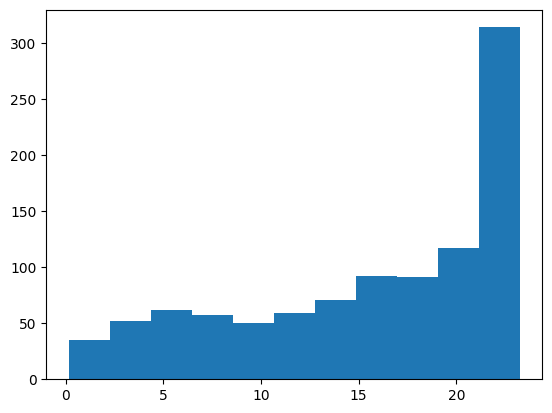

In [177]:
plt.figure()
plt.hist(x - y, bins="auto")
plt.show()

In [98]:
x

array([[ 6.70796955e-01,  3.67347461e-02, -2.95310680e-01],
       [-4.59447860e-01,  4.49392259e-01,  2.09337490e-01],
       [ 2.04511038e-01, -9.53165029e-01, -1.04402673e-01],
       [-7.56633493e-01, -3.69626858e-01,  3.28209173e-01],
       [-4.70035473e-01, -5.25652566e-01,  1.99479048e-01],
       [ 4.98131653e-01, -7.09611084e-01, -2.30276419e-01],
       [ 7.11552840e-01,  1.98191491e-01, -3.10880541e-01],
       [ 7.15060118e-01,  1.94436074e-01, -3.12483397e-01],
       [-2.99008385e-01,  4.84641211e-01,  1.39100155e-01],
       [-4.86700700e-01,  8.09311944e-01,  2.26720286e-01],
       [-8.50830153e-01,  3.49824766e-01,  3.80474864e-01],
       [-4.18897355e-01, -7.39826884e-01,  1.73733146e-01],
       [ 7.87342424e-01, -3.89402781e-01, -3.53063026e-01],
       [-3.78178158e-01, -1.87106585e-03,  1.66769310e-01],
       [ 8.22142986e-01,  7.72218372e-02, -3.61459270e-01],
       [-1.33127050e-01,  2.48853798e-01,  6.24242003e-02],
       [ 4.76124238e-01,  8.09331353e-01

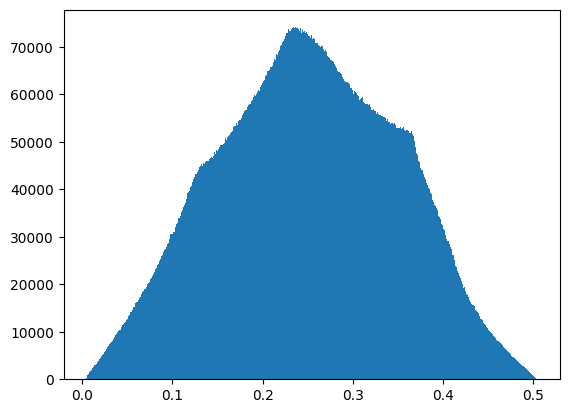

In [44]:
plt.figure()
plt.hist(np.arccos(cos_phi) / np.pi, bins="auto")
plt.show()

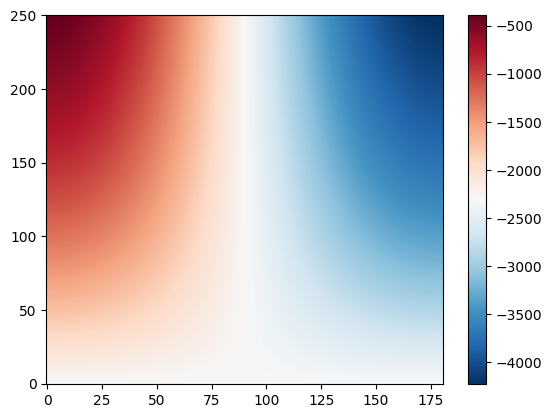

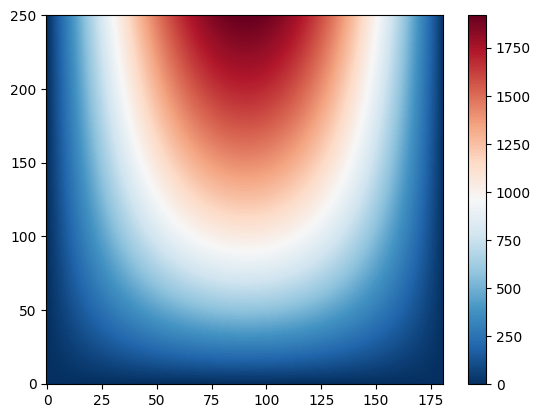

In [14]:
plt.figure()
plt.imshow(vx[0], origin="lower", cmap="RdBu_r", aspect="auto", )
plt.colorbar()

plt.show()

plt.figure()
plt.imshow(vy[0], origin="lower", cmap="RdBu_r", aspect="auto", )
plt.colorbar()

plt.show()